In [1]:
import pandas as pd

df = pd.read_excel("STTHK3033_FA_SectionA(Q4).xlsx")

print(df.head())
print(df.columns)
print(df.shape)

        Tick_ID          Buyer_Entity          Seller_Entity Ticker_Symbol  \
0  TICK_1000000       JP_Morgan_Bot_A      Goldman_Sachs_HFT          AMZN   
1  TICK_1000001       JP_Morgan_Bot_A        DRW_Trading_LTD          AAPL   
2  TICK_1000002  Virtu_Financial_Node        DRW_Trading_LTD         GOOGL   
3  TICK_1000003       DRW_Trading_LTD  Morgan_Stanley_Router          NVDA   
4  TICK_1000004       Citadel_Algo_04  Morgan_Stanley_Router          TSLA   

  Order_Type    Strategy_Used  Execution_Price  Trade_Volume  
0  Stop-Loss        Arbitrage           189.28           764  
1    Iceberg  Trend_Following           111.92           233  
2      Limit        Arbitrage           386.41           728  
3    Iceberg    Market_Making           423.77            16  
4  Stop-Loss        Arbitrage           186.13           791  
Index(['Tick_ID', 'Buyer_Entity', 'Seller_Entity', 'Ticker_Symbol',
       'Order_Type', 'Strategy_Used', 'Execution_Price', 'Trade_Volume'],
      dtype

#### Visualization 1: Force-Directed Node-Link Diagram

In [2]:
pip install networkx matplotlib

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
    --------------------------------------- 0.0/2.1 MB 330.3 kB/s eta 0:00:07
   - -------------------------------------- 0.1/2.1 MB 438.9 kB/s eta 0:00:05
   - -------------------------------------- 0.1/2.1 MB 492.8 kB/s eta 0:00:04
   -- ------------------------------------- 0.2/2.1 MB 612.6 kB/s eta 0:00:04
   --- ------------------------------------ 0.2/2.1 MB 692.4 kB/s eta 0:00:03
   ---- ----------------------------------- 0.2/2.1 MB 722.1 kB/s eta 0:00:03
   ----- ---------------------------------- 0.3/2.1 MB 713.1 kB/s eta 0:00:03
   ------ --------------------------------- 0.3/2.1 MB 756.6 kB/s eta 0:00:03
   ------- -------------------------------- 0.4/2.1 MB 820.1 kB/s eta 0:00:03
   -------- ------------------------------- 0.4/2.1 MB 846.3 kB/s eta 0:00:02
   --------- 


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_excel("STTHK3033_FA_SectionA(Q4).xlsx")

In [5]:
print(df.columns.tolist())

['Tick_ID', 'Buyer_Entity', 'Seller_Entity', 'Ticker_Symbol', 'Order_Type', 'Strategy_Used', 'Execution_Price', 'Trade_Volume']


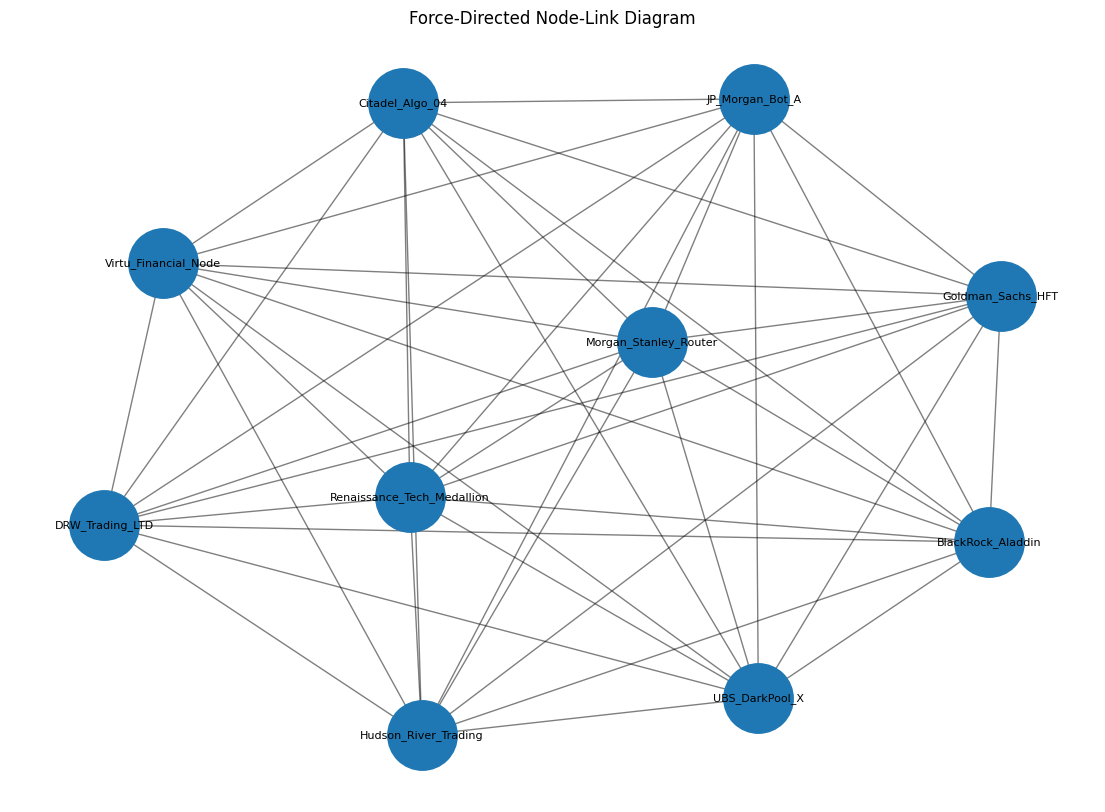

In [10]:

G = nx.from_pandas_edgelist(
    df,
    source='Buyer_Entity',
    target='Seller_Entity'
)

sample_nodes = list(G.nodes())[:20]
subG = G.subgraph(sample_nodes)

# Create node positions
pos = nx.spring_layout(subG, seed=42)

plt.figure(figsize=(14,10))

nx.draw_networkx_nodes(
    subG,
    pos,
    node_size=2500
)

nx.draw_networkx_edges(
    subG,
    pos,
    alpha=0.5
)

nx.draw_networkx_labels(
    subG,
    pos,
    font_size=8
)

plt.title("Force-Directed Node-Link Diagram")
plt.axis("off")
plt.show()

#### Visualization 2: Adjacency Matrix

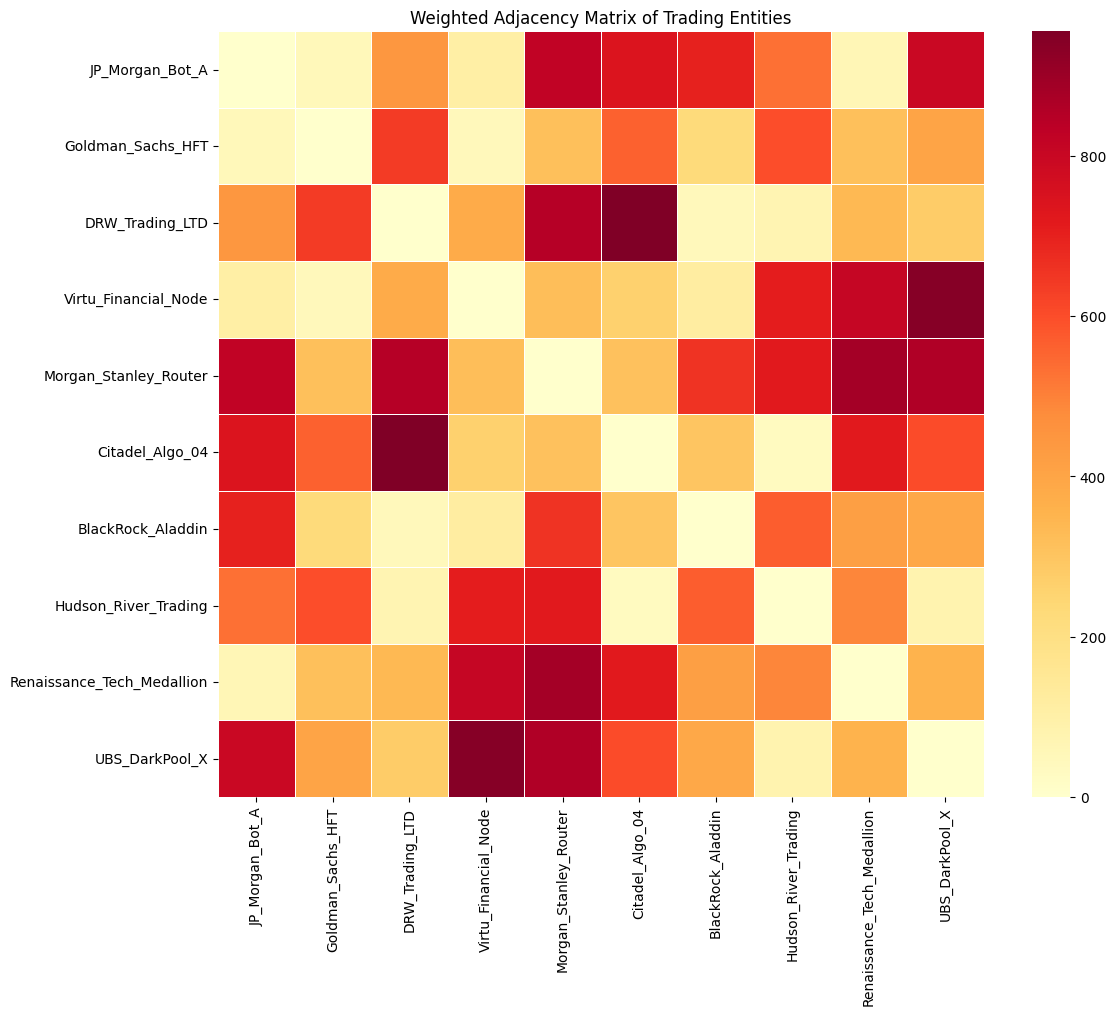

In [16]:
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("STTHK3033_FA_SectionA(Q4).xlsx")

G = nx.from_pandas_edgelist(
    df,
    source='Buyer_Entity',
    target='Seller_Entity',
    edge_attr='Trade_Volume'
)

top_nodes = [n for n, d in sorted(G.degree, key=lambda x: x[1], reverse=True)[:20]]

subG = G.subgraph(top_nodes)

adj_matrix = nx.to_pandas_adjacency(
    subG,
    weight='Trade_Volume'
)

plt.figure(figsize=(12,10))

sns.heatmap(
    adj_matrix,
    cmap='YlOrRd',
    square=True,
    linewidths=0.5
)

plt.title("Weighted Adjacency Matrix of Trading Entities")
plt.tight_layout()
plt.show()